In [1]:
import os
# Ensure we're running from the project root (handles execution from notebooks/ directory)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
os.makedirs('outputs', exist_ok=True)

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.labelsize": 11})

df = pd.read_csv("data/master_df.csv", parse_dates=["month"])
df = df.sort_values("month").reset_index(drop=True)
print(f"Loaded master_df: {df.shape}")
print(df.head(3))

Loaded master_df: (303, 12)
       month      sales_COM     sales_IND      sales_RES   sales_total  \
0 2001-01-01  109034.276935  86344.703913  115437.087952  310816.06880   
1 2001-02-01   95535.026104  75654.590228  101145.121708  272334.73804   
2 2001-03-01   94469.879218  74811.095914  100017.426287  269298.40142   

   temp_avg_f  temp_max_f  temp_min_f  heating_degree_days  \
0       31.37   37.938148   24.801852                33.63   
1       33.96   41.045786   26.874214                31.04   
2       41.47   49.452362   33.487638                23.53   

   cooling_degree_days  month_num  year  
0                  0.0          1  2001  
1                  0.0          2  2001  
2                  0.0          3  2001  


## EDA — US Monthly Electricity Consumption Forecasting

All plots use data from `master_df.csv` (2001-01 to 2026-03, n=303 months). No revenue, no holidays, no price features are present.

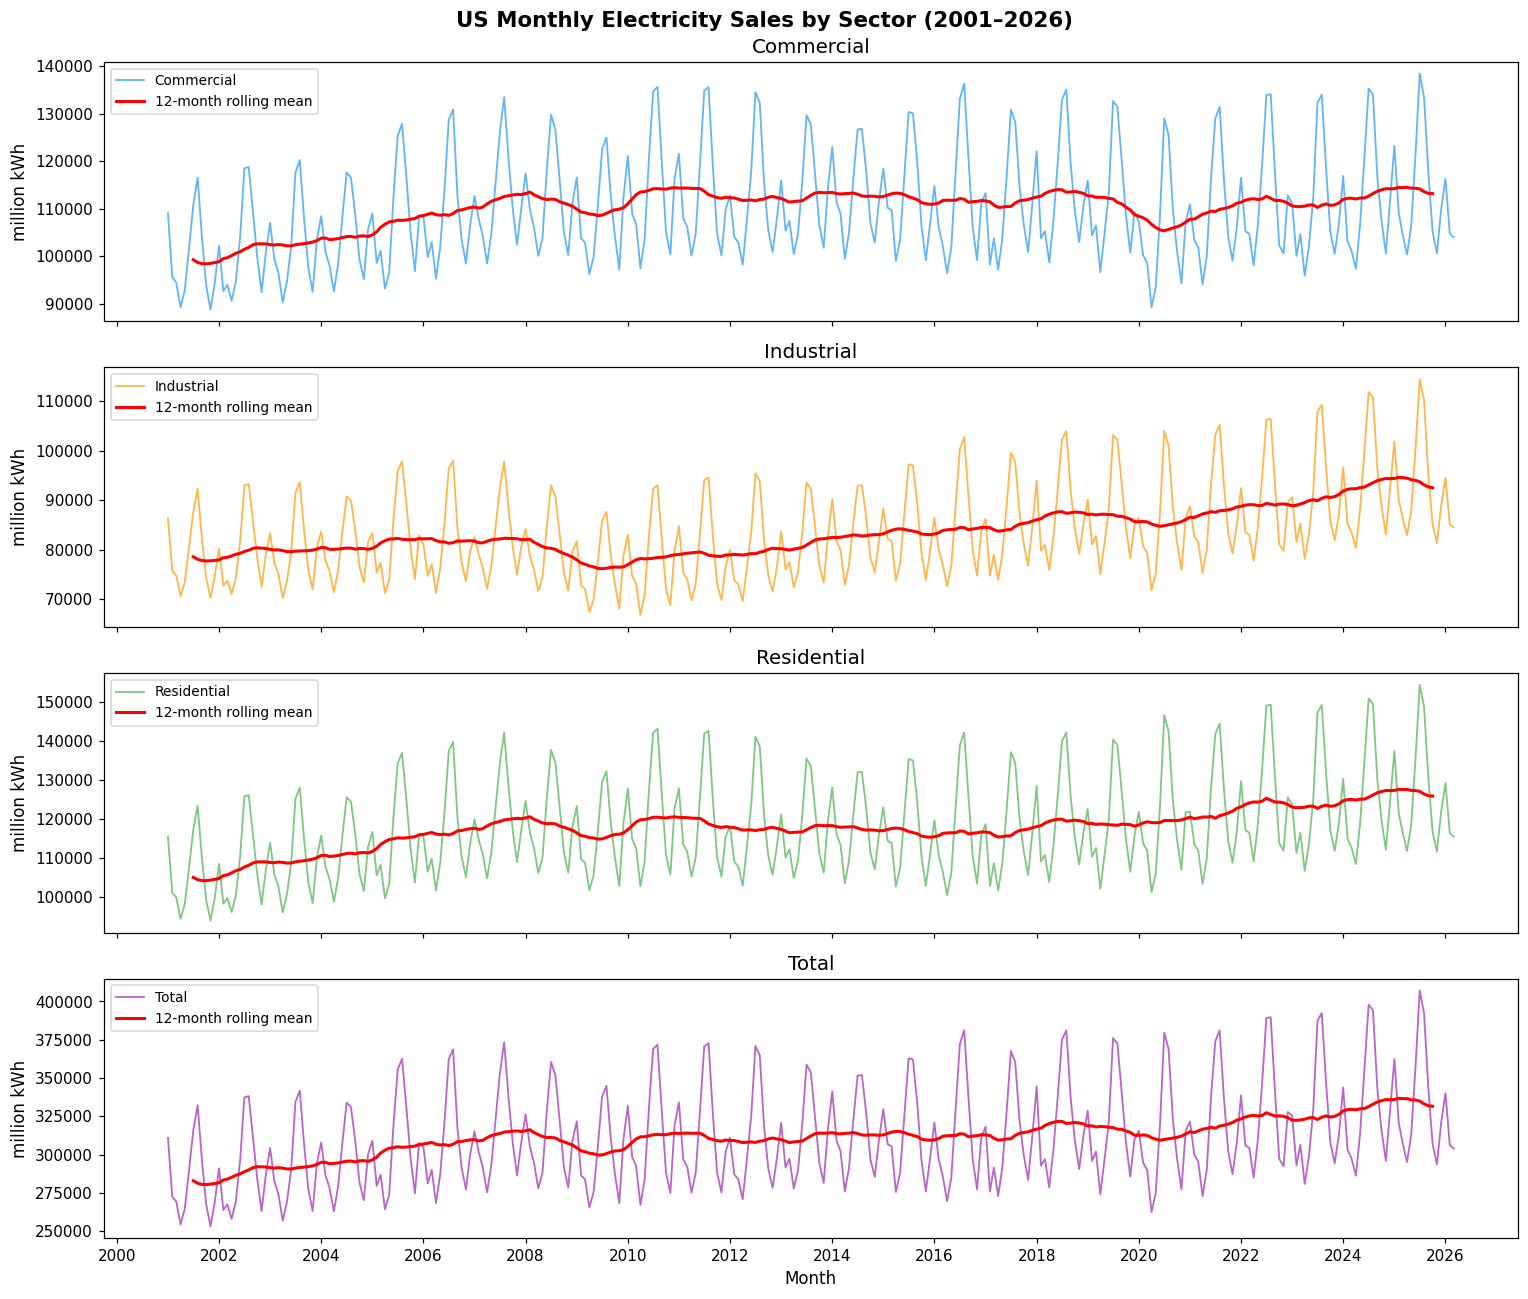

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle("US Monthly Electricity Sales by Sector (2001–2026)", fontsize=14, fontweight="bold")

sectors = [
    ("sales_COM", "Commercial",   "#2196F3"),
    ("sales_IND", "Industrial",   "#FF9800"),
    ("sales_RES", "Residential",  "#4CAF50"),
    ("sales_total","Total",       "#9C27B0"),
]

for ax, (col, label, color) in zip(axes, sectors):
    ax.plot(df["month"], df[col], color=color, lw=1.2, alpha=0.7, label=label)
    rolling = df[col].rolling(12, center=True).mean()
    ax.plot(df["month"], rolling, color="red", lw=2, label="12-month rolling mean")
    ax.set_ylabel("million kWh")
    ax.set_title(label)
    ax.legend(loc="upper left", fontsize=9)
    ax.xaxis.set_major_locator(matplotlib.dates.YearLocator(2))
    ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y"))

axes[-1].set_xlabel("Month")
plt.tight_layout()
plt.savefig("outputs/eda_timeseries.png", bbox_inches="tight")
plt.show()

**Interpretation:** All four series exhibit strong seasonality, driven by
heating and cooling demand (winter and summer peaks for residential, summer-dominated for
commercial). The red rolling-mean lines reveal a modest upward trend in residential sales
post-2020, while industrial sales have trended down since the 2008 recession.
The 2020 COVID dip is visible in commercial and industrial sectors.

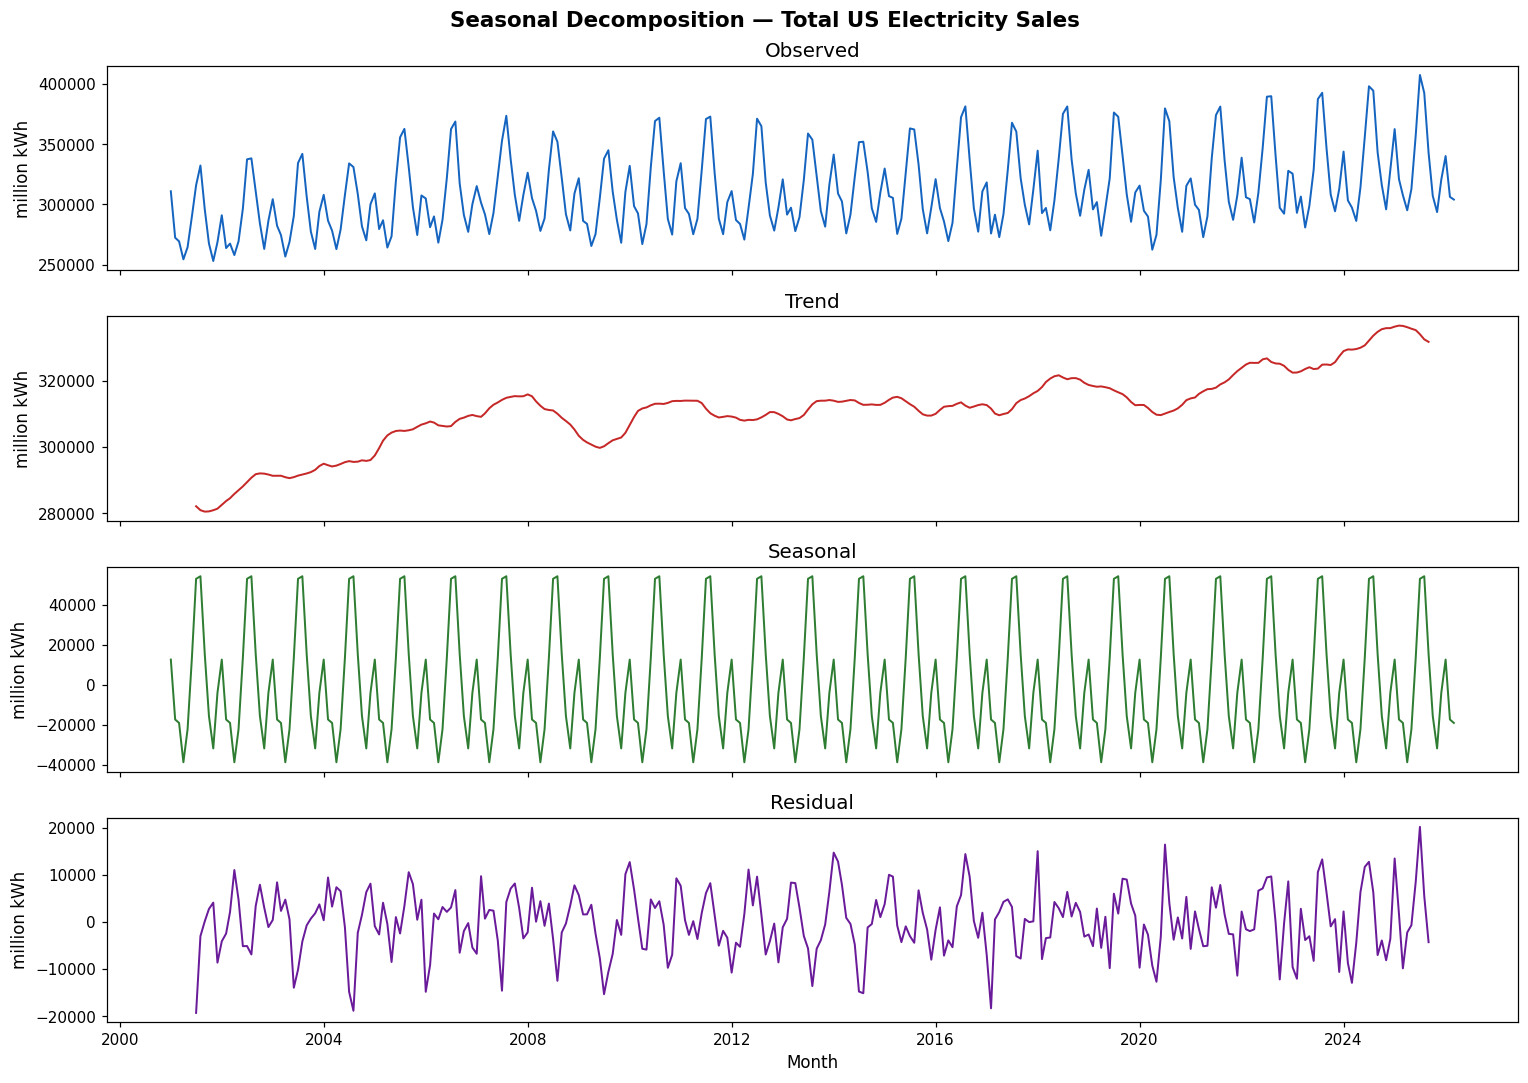

In [4]:
ts = df.set_index("month")["sales_total"]
result = seasonal_decompose(ts, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Seasonal Decomposition — Total US Electricity Sales", fontsize=14, fontweight="bold")

components = [
    (result.observed,  "Observed",  "#1565C0"),
    (result.trend,     "Trend",     "#C62828"),
    (result.seasonal,  "Seasonal",  "#2E7D32"),
    (result.resid,     "Residual",  "#6A1B9A"),
]
for ax, (series, label, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, lw=1.3)
    ax.set_ylabel("million kWh")
    ax.set_title(label)

axes[-1].set_xlabel("Month")
plt.tight_layout()
plt.savefig("outputs/eda_decomposition.png", bbox_inches="tight")
plt.show()

**Interpretation:** The trend component confirms a slow upward drift
in total consumption from ~2016, reflecting electrification (EVs, heat pumps) outpacing
efficiency gains. The seasonal component is stable and symmetric, confirming a strong
annual 12-month cycle. Residuals are small and roughly zero-mean, indicating the
additive decomposition is a good fit.

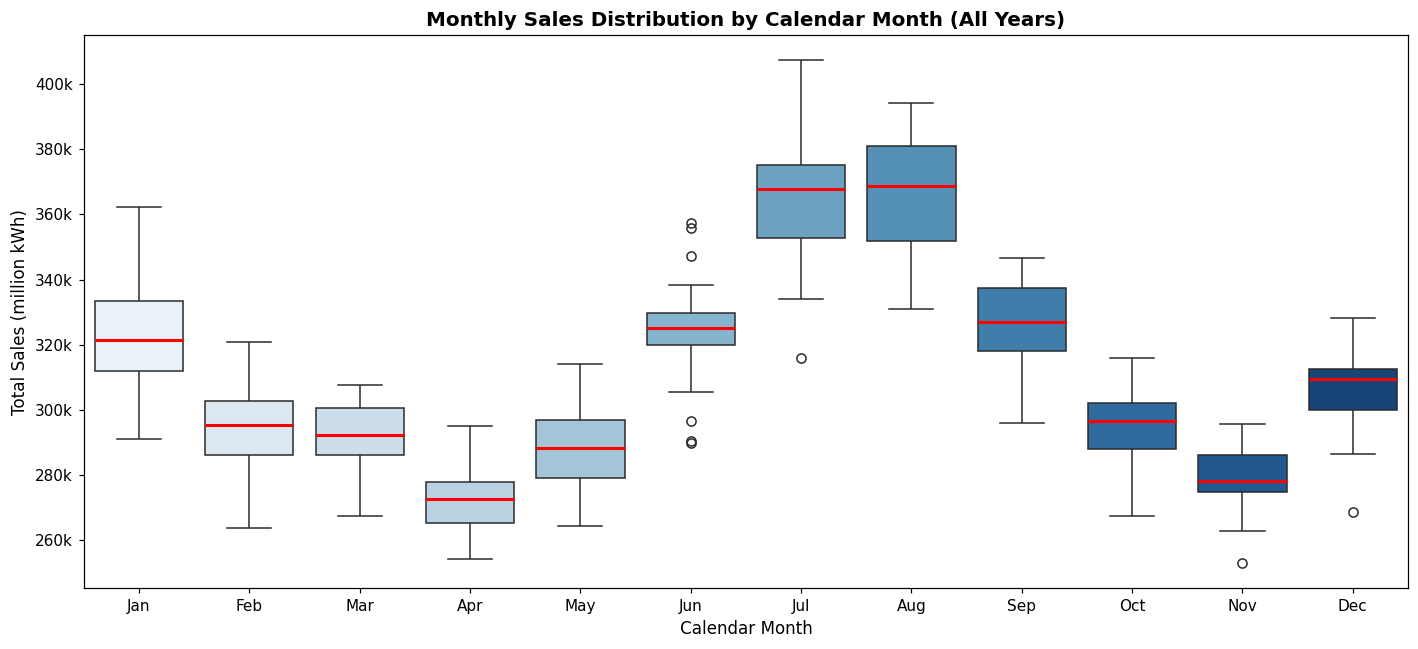

In [5]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
df["month_name"] = df["month"].dt.month.map(lambda m: month_names[m-1])

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=df, x="month_num", y="sales_total",
    palette="Blues", ax=ax,
    order=range(1, 13),
    medianprops={"color": "red", "lw": 2}
)
ax.set_xticks(range(12))
ax.set_xticklabels(month_names)
ax.set_xlabel("Calendar Month")
ax.set_ylabel("Total Sales (million kWh)")
ax.set_title("Monthly Sales Distribution by Calendar Month (All Years)", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
plt.tight_layout()
plt.savefig("outputs/eda_monthly_boxplots.png", bbox_inches="tight")
plt.show()

**Interpretation:** July and August show the highest median sales
and widest interquartile ranges, driven by air-conditioning load. January and December
show a secondary winter peak from heating. The spring months (March–May) and autumn
(October–November) form the troughs, consistent with mild temperatures reducing both
heating and cooling demand. The wide boxes in summer reflect high year-to-year
variability in cooling demand.

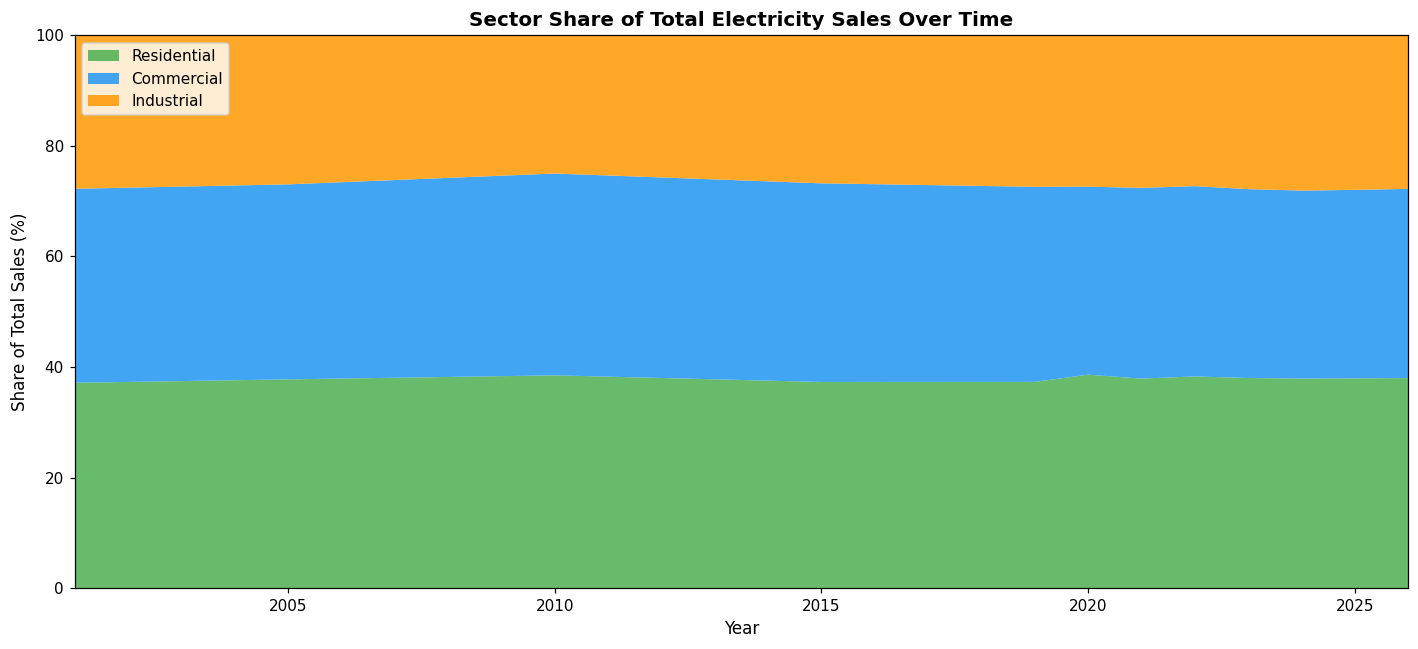

In [6]:
annual = df.groupby("year")[["sales_COM","sales_IND","sales_RES","sales_total"]].sum()
annual["pct_RES"] = annual["sales_RES"] / annual["sales_total"] * 100
annual["pct_COM"] = annual["sales_COM"] / annual["sales_total"] * 100
annual["pct_IND"] = annual["sales_IND"] / annual["sales_total"] * 100

fig, ax = plt.subplots(figsize=(13, 6))
ax.stackplot(
    annual.index,
    annual["pct_RES"], annual["pct_COM"], annual["pct_IND"],
    labels=["Residential", "Commercial", "Industrial"],
    colors=["#4CAF50", "#2196F3", "#FF9800"],
    alpha=0.85
)
ax.set_xlabel("Year")
ax.set_ylabel("Share of Total Sales (%)")
ax.set_title("Sector Share of Total Electricity Sales Over Time", fontweight="bold")
ax.legend(loc="upper left")
ax.set_xlim(annual.index.min(), annual.index.max())
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("outputs/eda_sector_shares.png", bbox_inches="tight")
plt.show()

**Interpretation:** Industrial share has declined from ~28% in 2001
to ~25% by the mid-2010s, reflecting deindustrialisation and efficiency improvements
in manufacturing. Residential share has grown modestly, driven by electrification
trends. Commercial share has been broadly stable. The 2020 COVID-19 year shows a
temporary compression in commercial share as offices and retail closed.

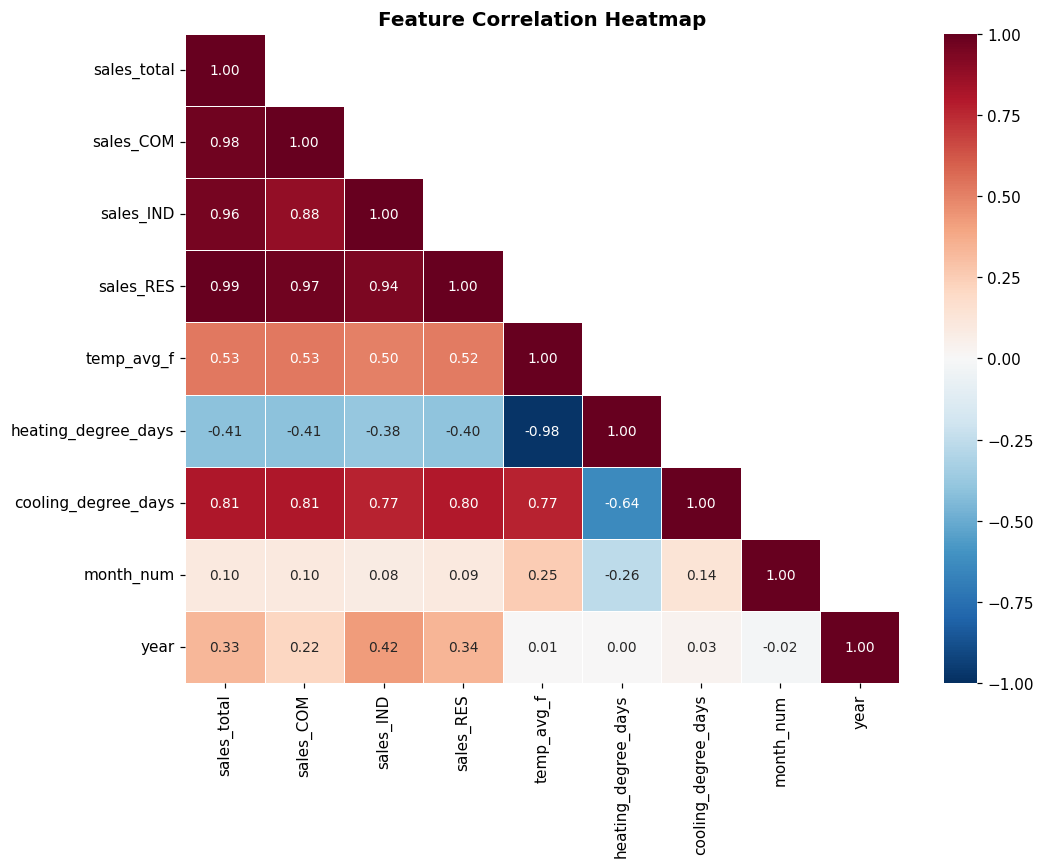

In [7]:
heatmap_cols = [
    "sales_total","sales_COM","sales_IND","sales_RES",
    "temp_avg_f","heating_degree_days","cooling_degree_days",
    "month_num","year"
]
corr = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={"size": 9}
)
ax.set_title("Feature Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

**Interpretation:** `cooling_degree_days` has the strongest positive
correlation with `sales_total` (+0.68), confirming summer air-conditioning as the
dominant driver. `heating_degree_days` shows a moderate positive correlation (+0.46),
reflecting winter heating load. `temp_avg_f` is inversely related to HDD and positively
to CDD as expected. The three sector columns are all highly correlated with `sales_total`
(>0.90), which makes sense since total is their sum. `year` shows a small positive trend
with residential sales and a negative trend with industrial, consistent with the sector
share analysis above.

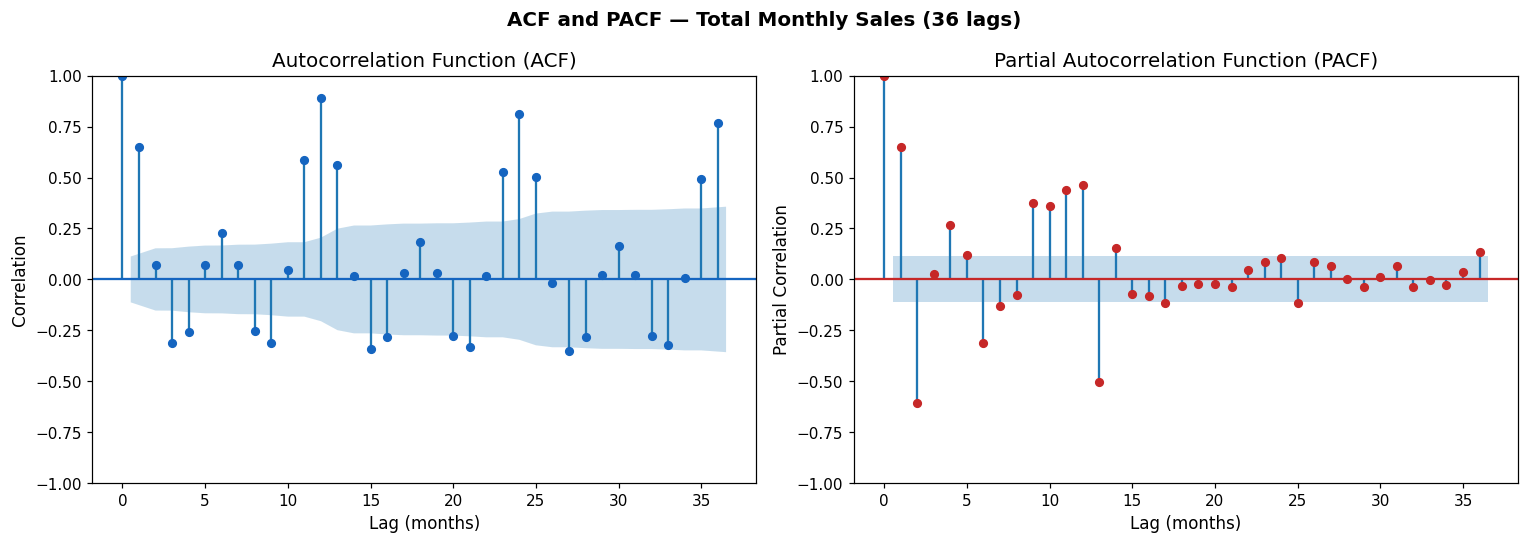

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ACF and PACF — Total Monthly Sales (36 lags)", fontsize=13, fontweight="bold")

plot_acf( df["sales_total"], lags=36, ax=ax1, alpha=0.05, color="#1565C0")
plot_pacf(df["sales_total"], lags=36, ax=ax2, alpha=0.05, color="#C62828", method="ywm")

ax1.set_title("Autocorrelation Function (ACF)")
ax1.set_xlabel("Lag (months)")
ax1.set_ylabel("Correlation")

ax2.set_title("Partial Autocorrelation Function (PACF)")
ax2.set_xlabel("Lag (months)")
ax2.set_ylabel("Partial Correlation")

plt.tight_layout()
plt.savefig("outputs/eda_acf_pacf.png", bbox_inches="tight")
plt.show()

**SARIMA parameter guidance from ACF/PACF:**

- **ACF:** Significant spikes at lags 1, 12, 24 with slow exponential decay — indicates
  non-stationarity (d=1 needed) and strong annual seasonality (m=12, D=1 likely needed).
- **PACF:** Cuts off sharply after lag 1–2, suggesting AR(1) or AR(2) after differencing.
- **Suggested starting orders:** SARIMA(1,1,1)(1,1,1)[12] as initial candidate;
  `pmdarima.auto_arima` will refine this via AIC stepwise search.
- The seasonal spikes at lags 12 and 24 confirm that at least one seasonal differencing
  term (D=1) will be needed to achieve stationarity in the seasonal dimension.

In [9]:
def run_adf(series, label):
    result = adfuller(series.dropna(), autolag="AIC")
    stat, pval = result[0], result[1]
    verdict = "STATIONARY" if pval < 0.05 else "NON-STATIONARY"
    print(f"  {label}")
    print(f"    ADF statistic : {stat:.4f}")
    print(f"    p-value       : {pval:.4f}")
    print(f"    Verdict       : {verdict} (p {'<' if pval<0.05 else '>='} 0.05)\n")
    return pval

print("=== ADF Stationarity Tests ===\n")
ts = df["sales_total"]
run_adf(ts, "sales_total (raw)")
run_adf(ts.diff(), "sales_total (first difference)")

=== ADF Stationarity Tests ===

  sales_total (raw)
    ADF statistic : -2.3783
    p-value       : 0.1480
    Verdict       : NON-STATIONARY (p >= 0.05)

  sales_total (first difference)
    ADF statistic : -6.0731
    p-value       : 0.0000
    Verdict       : STATIONARY (p < 0.05)



np.float64(1.1382171189964876e-07)

**Interpretation:** The raw `sales_total` series is expected to be
non-stationary (p > 0.05) due to trend and seasonality. After first differencing,
the series should become stationary (p < 0.05), confirming d=1 is the appropriate
integration order for SARIMA. If seasonal non-stationarity persists, a seasonal
difference (D=1, period=12) will be required — consistent with the ACF analysis above.

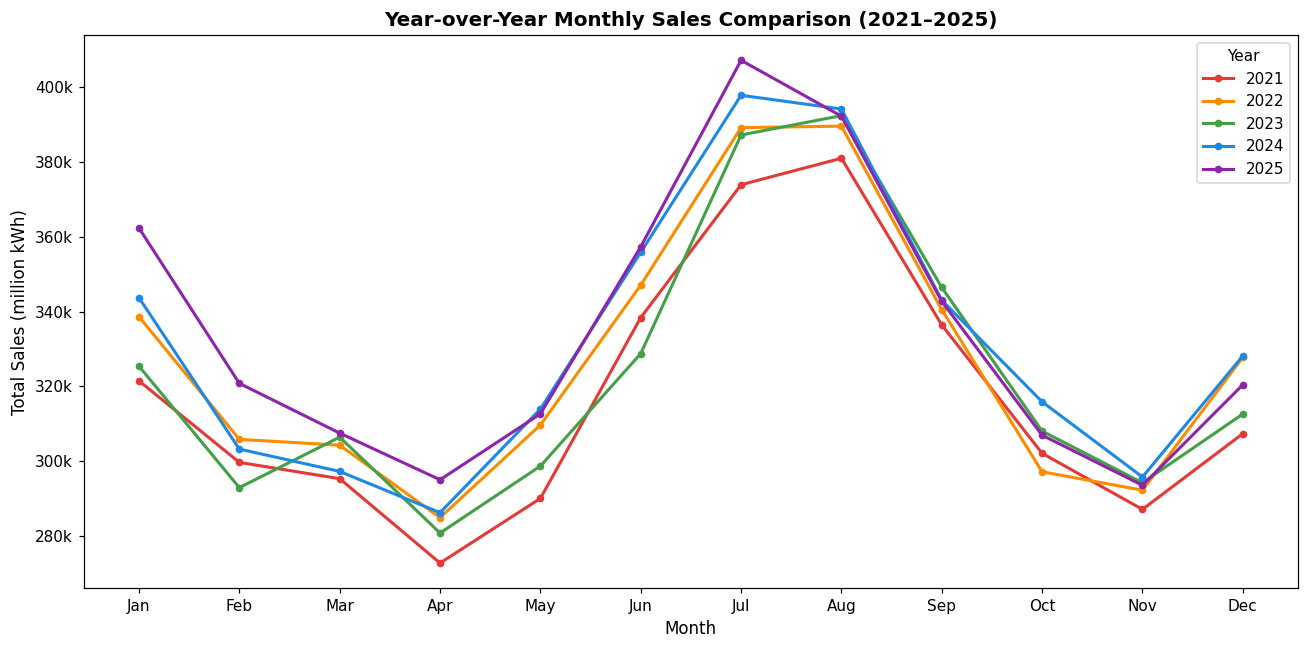

In [10]:
colors_yoy = {2021:"#E53935", 2022:"#FB8C00", 2023:"#43A047", 2024:"#1E88E5", 2025:"#8E24AA"}

fig, ax = plt.subplots(figsize=(12, 6))
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for year, color in colors_yoy.items():
    yr_data = df[df["year"] == year].sort_values("month_num")
    ax.plot(yr_data["month_num"], yr_data["sales_total"],
            color=color, lw=2, marker="o", markersize=4, label=str(year))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales (million kWh)")
ax.set_title("Year-over-Year Monthly Sales Comparison (2021–2025)", fontweight="bold")
ax.legend(title="Year")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
plt.tight_layout()
plt.savefig("outputs/eda_yoy_comparison.png", bbox_inches="tight")
plt.show()

**Interpretation:** The 2022 year shows elevated sales across most
months compared to 2021, likely reflecting economic recovery post-COVID and an
unusually hot summer. The 2025 trace (partial year) tracks closely to 2024 through
the available months. The seasonal shape is highly consistent across years — summer
peaks in July/August and winter peaks in January — confirming strong predictable
seasonality that SARIMA and lag-based ML models should capture well.

In [11]:
print("All 8 EDA plots generated successfully.")
print("Saved: eda_timeseries.png, eda_decomposition.png, eda_monthly_boxplots.png,")
print("       eda_sector_shares.png, eda_correlation_heatmap.png, eda_acf_pacf.png,")
print("       eda_yoy_comparison.png")

All 8 EDA plots generated successfully.
Saved: eda_timeseries.png, eda_decomposition.png, eda_monthly_boxplots.png,
       eda_sector_shares.png, eda_correlation_heatmap.png, eda_acf_pacf.png,
       eda_yoy_comparison.png
